<a href="https://colab.research.google.com/github/nissi31/projects/blob/main/image_correspondence_cv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Classic Computer Vision Approach (ORB Feature Matching)


Images loaded successfully.
Detecting keypoints...
Found 3449 raw keypoints in image 1 and 5508 in image 2.
Extracting descriptors (and filtering keypoints near borders)...
Extracted 3303 descriptors from image 1 and 5295 from image 2.
Matching features...
Kept 0 good matches after ratio test.


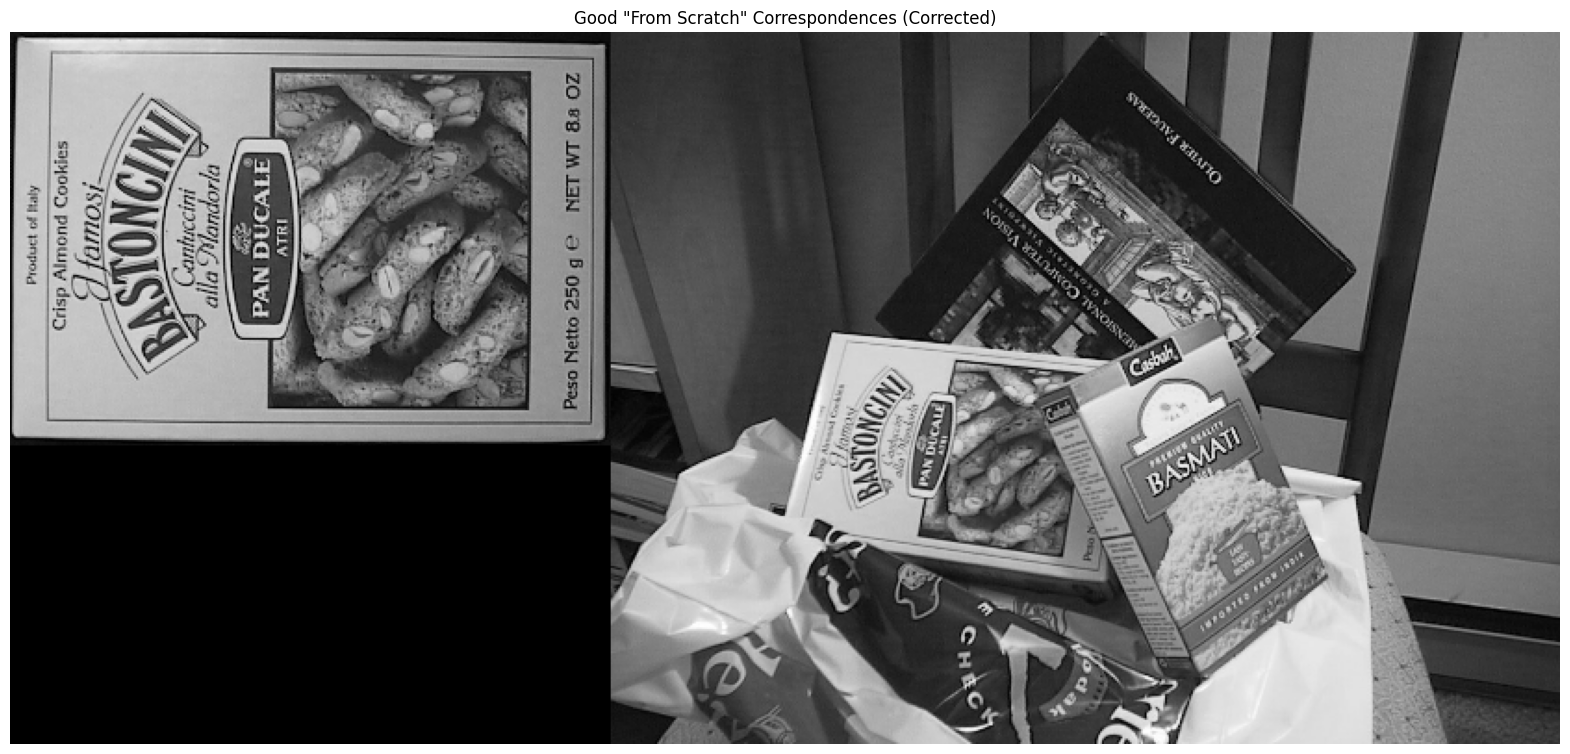

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

!wget https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box.png -O box.png
!wget https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box_in_scene.png -O box_in_scene.png

# img1 is the "object" or "template" we want to find
# img2 is the "scene" where we want to find it
img1 = cv2.imread('box.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('box_in_scene.png', cv2.IMREAD_GRAYSCALE)

if img1 is None or img2 is None:
    print("Error: Could not load images. Check paths.")
else:
    print("Images loaded successfully.")

    orb = cv2.ORB_create(nfeatures=1000)

    keypoints1, descriptors1 = orb.detectAndCompute(img1, None)
    keypoints2, descriptors2 = orb.detectAndCompute(img2, None)
    print(f"Found {len(keypoints1)} keypoints in image 1 and {len(keypoints2)} in image 2.")

    bf_matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)

    # knnMatch finds the 'k' best matches for each descriptor. We use k=2.
    raw_matches = bf_matcher.knnMatch(descriptors1, descriptors2, k=2)
    print(f"Found {len(raw_matches)} raw matches.")

    good_matches = []
    ratio_threshold = 0.75
    for m, n in raw_matches:
        if m.distance < ratio_threshold * n.distance:
            good_matches.append(m)
    print(f"Kept {len(good_matches)} good matches after ratio test.")

    result_image = cv2.drawMatches(
        img1, keypoints1,
        img2, keypoints2,
        good_matches,
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    plt.figure(figsize=(20, 10))
    plt.imshow(result_image)
    plt.title('Good ORB Correspondences')
    plt.axis('off')
    plt.show()

#Classic Computer Vision Approach (SIFT)

--2025-07-09 09:43:12--  https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50728 (50K) [image/png]
Saving to: ‘box.png’

box.png             100%[===================>]  49.54K  --.-KB/s    in 0.009s  

2025-07-09 09:43:12 (5.19 MB/s) - ‘box.png’ saved [50728/50728]

--2025-07-09 09:43:12--  https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box_in_scene.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 122490 (120K) [image/png]
Saving to: 

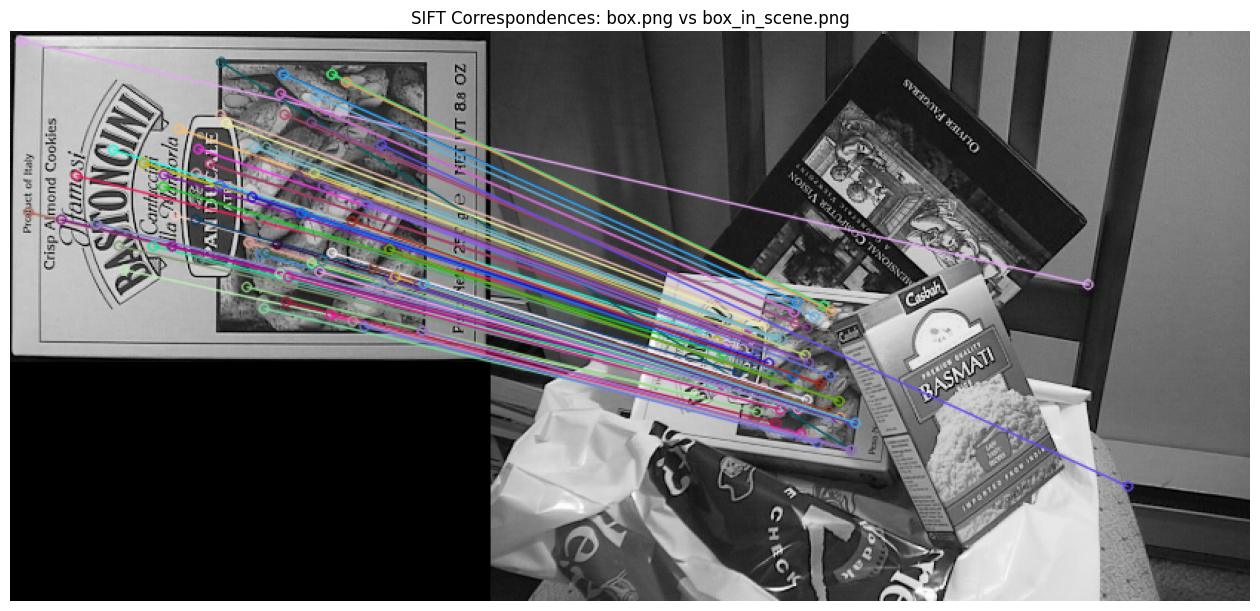

In [ ]:
!pip install opencv-contrib-python --quiet

!wget https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box.png -O box.png
!wget https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box_in_scene.png -O box_in_scene.png

import cv2
import numpy as np
import matplotlib.pyplot as plt

img1 = cv2.imread('box.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('box_in_scene.png', cv2.IMREAD_GRAYSCALE)

sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append([m])

matched_img = cv2.drawMatchesKnn(img1, kp1, img2, kp2, good_matches, None, flags=2)

plt.figure(figsize=(16, 8))
plt.imshow(matched_img, cmap='gray')
plt.title('SIFT Correspondences: box.png vs box_in_scene.png')
plt.axis('off')
plt.show()

#Classic Computer Vision Approach (RANSAC)

--2025-07-10 06:09:39--  https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50728 (50K) [image/png]
Saving to: ‘box.png’

box.png             100%[===================>]  49.54K  --.-KB/s    in 0.002s  

2025-07-10 06:09:39 (30.6 MB/s) - ‘box.png’ saved [50728/50728]

--2025-07-10 06:09:39--  https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box_in_scene.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 122490 (120K) [image/png]
Saving to: 

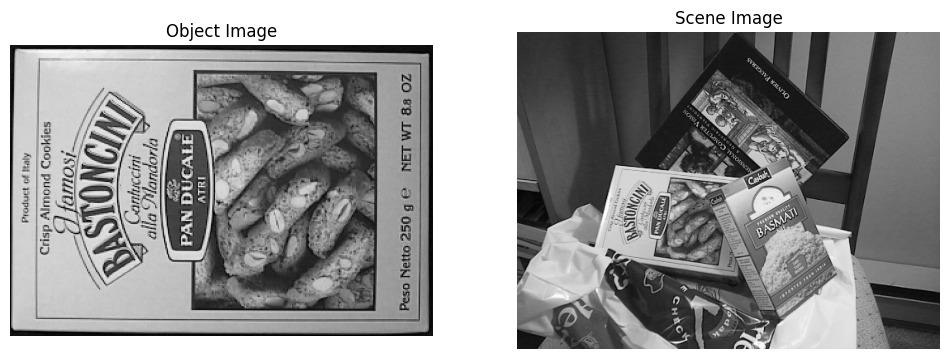


Found 1589 keypoints in image 1 and 1999 in image 2.


Found 53 potential matches after ratio test.



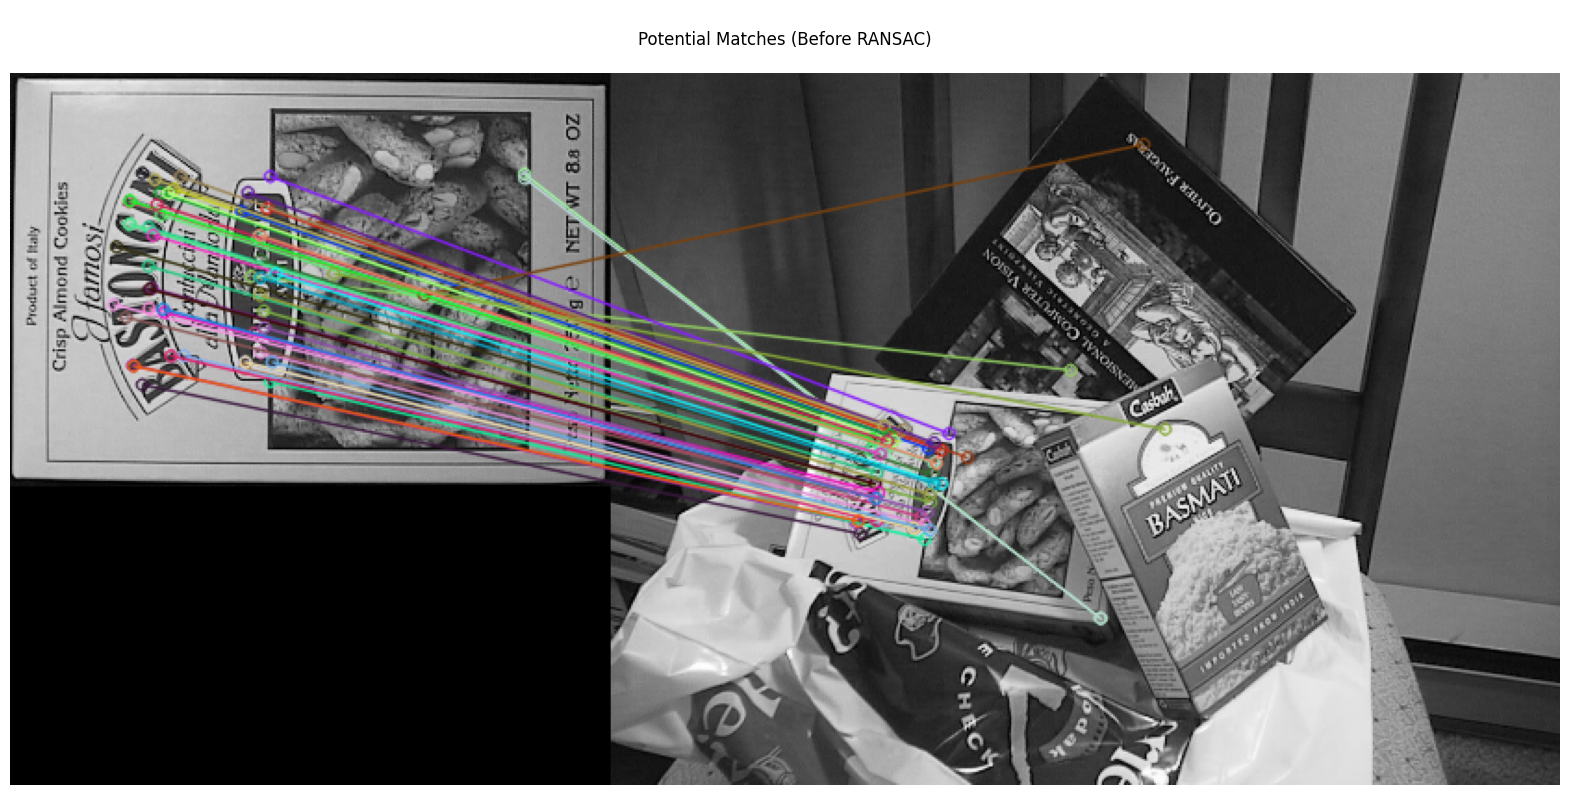


RANSAC identified 48 inlier matches.



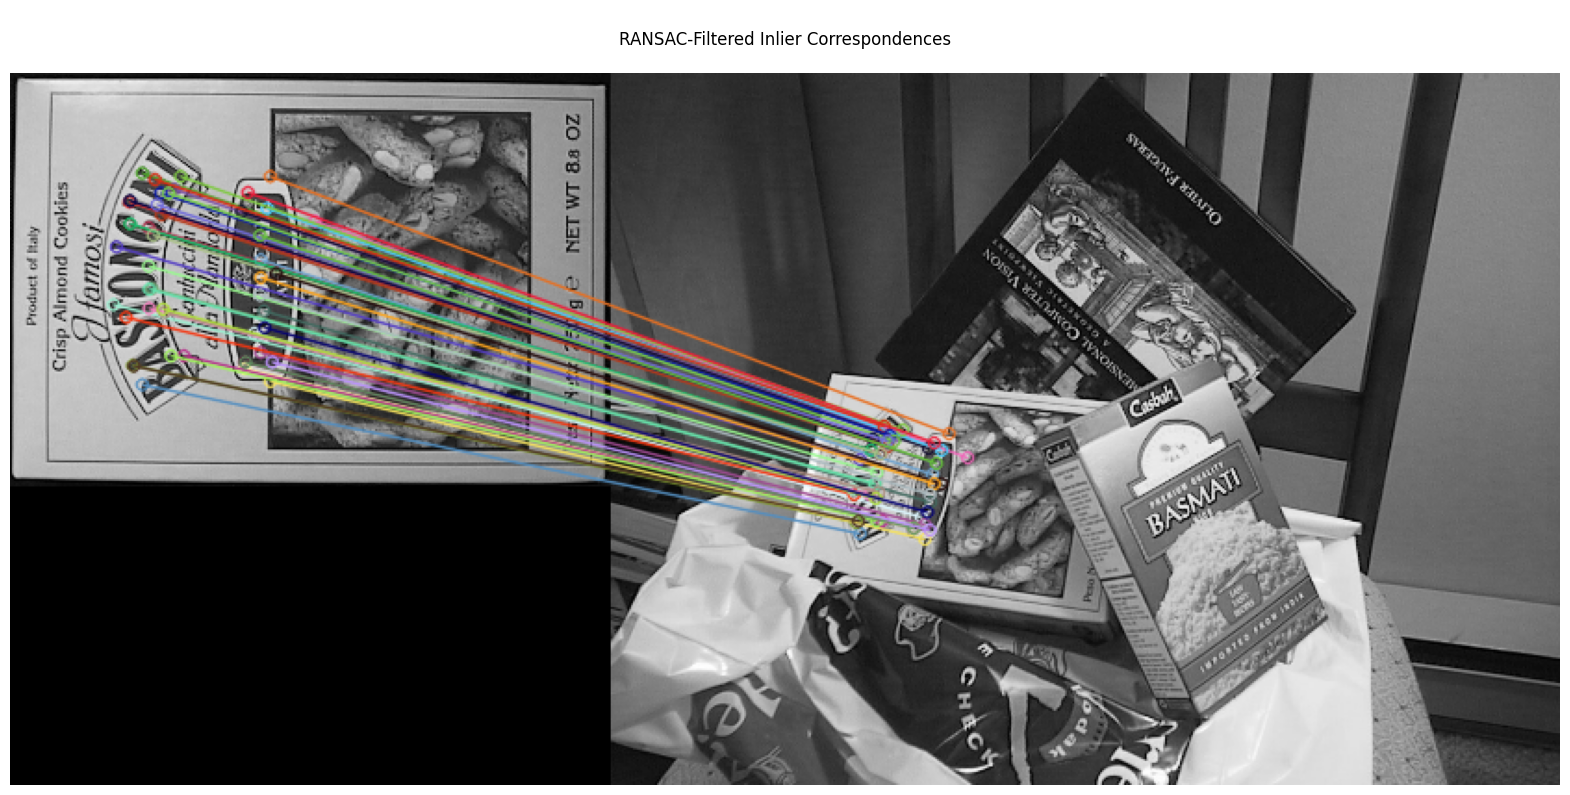

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

!wget https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box.png -O box.png
!wget https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box_in_scene.png -O box_in_scene.png

img1 = cv2.imread('box.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('box_in_scene.png', cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(img1, cmap='gray'); plt.title('Object Image'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(img2, cmap='gray'); plt.title('Scene Image'); plt.axis('off')
plt.show()

orb = cv2.ORB_create(nfeatures=2000)
keypoints1, descriptors1 = orb.detectAndCompute(img1, None)
keypoints2, descriptors2 = orb.detectAndCompute(img2, None)
print(f"\nFound {len(keypoints1)} keypoints in image 1 and {len(keypoints2)} in image 2.\n")

bf_matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
raw_matches = bf_matcher.knnMatch(descriptors1, descriptors2, k=2)

good_initial_matches = []
ratio_threshold = 0.75
for m, n in raw_matches:
    if m.distance < ratio_threshold * n.distance:
        good_initial_matches.append(m)
print(f"\nFound {len(good_initial_matches)} potential matches after ratio test.\n")

img_matches_before_ransac = cv2.drawMatches(
    img1, keypoints1,
    img2, keypoints2,
    good_initial_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(20, 10))
plt.imshow(img_matches_before_ransac)
plt.title('\nPotential Matches (Before RANSAC)\n')
plt.axis('off')
plt.show()

if len(good_initial_matches) > 4:
    src_pts = np.float32([keypoints1[m.queryIdx].pt for m in good_initial_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([keypoints2[m.trainIdx].pt for m in good_initial_matches]).reshape(-1, 1, 2)

    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    matches_mask = mask.ravel().tolist()
    print(f"\nRANSAC identified {np.sum(matches_mask)} inlier matches.\n")

    img_matches_after_ransac = cv2.drawMatches(
        img1, keypoints1,
        img2, keypoints2,
        good_initial_matches,
        None,
        matchesMask=matches_mask,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    plt.figure(figsize=(20, 10))
    plt.imshow(img_matches_after_ransac)
    plt.title('\nRANSAC-Filtered Inlier Correspondences\n')
    plt.axis('off')
    plt.show()

else:
    print("\nNot enough matches were found to apply RANSAC.\n")